# CC Calls — Exploratory Data Analysis
Target variable is joined from `billings_eda.csv`

## 1. Load Data & Join Target

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import math

# Load cc_calls
df_calls = pd.read_csv('../../dataset/02_basic_clean/cc_calls.csv')

# Load billings EDA (which has the target column)
df_billing_eda = pd.read_csv('../../dataset/03_EDA/billings/billings_eda.csv')

print("cc_calls shape:", df_calls.shape)
print("billings_eda shape:", df_billing_eda.shape)

cc_calls shape: (32789, 33)
billings_eda shape: (113894, 56)


C:\Users\Asus\AppData\Local\Temp\ipykernel_40444\897695672.py:11: DtypeWarning: Columns (10,11,47,48) have mixed types. Specify dtype option on import or set low_memory=False.
  df_billing_eda = pd.read_csv('../../dataset/03_EDA/billings/billings_eda.csv')


In [2]:
df_calls.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32789 entries, 0 to 32788
Data columns (total 33 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Contact_ID                                32789 non-null  float64
 1   Call_Date                                 32789 non-null  object 
 2   Direction                                 32789 non-null  object 
 3   cc_care_package                           32652 non-null  object 
 4   cc_care_package_discussed                 32652 non-null  object 
 5   cc_urgency_getting_on_site                32652 non-null  object 
 6   cc_external_consultant                    32652 non-null  object 
 7   cc_agent_cross_sell_attempt               32652 non-null  object 
 8   cc_customer_issues_concerns               32652 non-null  object 
 9   cc_business_struggles_financial_hardship  32652 non-null  object 
 10  cc_call_initiated_by              

In [3]:
df_calls.head()

,Contact_ID,Call_Date,Direction,cc_care_package,cc_care_package_discussed,cc_urgency_getting_on_site,cc_external_consultant,cc_agent_cross_sell_attempt,cc_customer_issues_concerns,cc_business_struggles_financial_hardship,...,cc_contractor_sentiment_overall_score,cc_contractor_sentiment_issues_score,cc_pricing_mentioned,cc_pricing_sentiment_impact,cc_refund_discussed,cc_contractor_suggest_leave,cc_contractor_complained,Co_Ref,Analysed_Call,Call_Year
0,6.255130e+11,08-05-2025,OUT_BOUND,Standard,Yes,No,No,No,Yes,Yes,...,30,20,yes,yes,no,Yes,Yes,HV3323,1,2025
1,5.910870e+11,25-11-2024,OUT_BOUND,Standard,Yes,No,No,No,Yes,No,...,0,0,yes,yes,no,Yes,Yes,PJ7066,1,2024
2,5.650910e+11,23-10-2024,IN_BOUND,Standard,Yes,No,No,No,Yes,No,...,40,20,yes,yes,no,Yes,Yes,DP6030,1,2024
3,5.939750e+11,13-01-2025,IN_BOUND,Premier,Yes,No,No,No,Yes,Yes,...,40,30,yes,yes,yes,Yes,Yes,AM2413,1,2025
4,6.222820e+11,19-03-2025,IN_BOUND,Standard,Yes,No,No,No,Yes,Yes,...,40,20,yes,yes,no,Yes,Yes,ED6707,1,2025


In [4]:
# Check available columns in billings_eda that can be used as join key
print("billings_eda columns:", df_billing_eda.columns.tolist())
print("cc_calls columns:", df_calls.columns.tolist())

billings_eda columns: ['Co_Ref', 'Renewal_Month', 'Discount_Amount', 'Sustainability_Score', 'Total_Renewal_Score_New', 'Last_Years_Price', 'Auto_Renewal_Score', 'Status_Scores', 'Anchoring_Score', 'Tenure_Scores', 'Proforma_Auto_Renewal', 'Proforma_World_Pay_Token', 'Proforma_Date', 'Current_Anchorings', 'Current_Anchor_List', 'Payment_Timeframe', 'Registration_Date', 'Proforma_Account_Stage', 'Proforma_Audit_Status', 'Current_Auto_Renewal_Flag', 'Current_World_Pay_Token', 'Renewal_Score_At_Release', 'Proforma_Membership_Status', 'Proforma_Approved_Lists', 'Tenure_Years', 'Band', 'Prospect_Renewal_Date', 'Closed_Date', 'Prospect_Status', 'Starting_Net', 'Starting_Vat', 'Starting_Gross', 'Starting_Membership_Net', 'Starting_Package_Net', 'Starting_PQQ_Net', 'Gross', 'Membership_Net', 'Package_Net', 'PQQNet', 'Total_Net_Paid', 'Prospect_Outcome', 'Payment_Method', 'Amount', 'Total_Amount', 'Connection_Group', 'Tenure_Group', '#_of_Connection', 'Last_Renewal', 'Last_Band', 'Last_Total_Ne

In [1]:
# df_merged = df_merged[
#     (df_merged["Call_Date"] <= df_merged["Prospect_Renewal_Date"]) &
#     (df_merged["Call_Date"] >= df_merged["Prospect_Renewal_Date"] - pd.Timedelta(days=14))
# ]

## JOIN CONCEPT

In [5]:
# TAKE DECISION
# Identify the correct join key between cc_calls and billings_eda
# Common candidates: 'Co_Ref', 'Customer_ID', 'Account_ID', etc.
# Set JOIN_KEY below after inspecting columns above

JOIN_KEY = 'Co_Ref'   # <-- UPDATE THIS if different

# Extract only the join key + target from billings
df_target = df_billing_eda[[JOIN_KEY, 'target']].drop_duplicates(subset=[JOIN_KEY])

print("Target distribution in billings_eda:")
print(df_target['target'].value_counts())

Target distribution in billings_eda:
target
0    35175
1    11164
Name: count, dtype: int64


In [6]:
# Join target onto cc_calls
df_calls = df_calls.merge(df_target, on=JOIN_KEY, how='inner')

print("After join shape:", df_calls.shape)
print("Target value counts:")
print(df_calls['target'].value_counts())

# Keep a backup for later comparison
db_calls_temp = df_calls.copy()

After join shape: (31078, 34)
Target value counts:
target
0    29901
1     1177
Name: count, dtype: int64


In [7]:
# TAKE DECISION
# Check how many rows were lost after the inner join.
# If significant, consider a left join and investigate unmatched rows.

lost = len(pd.read_csv('../../dataset/02_basic_clean/cc_calls.csv')) - len(df_calls)
print(f"Rows lost after join: {lost}")

Rows lost after join: 1711


---
## 2. Target Variable Analysis

In [8]:
print("Target unique values:", df_calls['target'].unique())
print(df_calls['target'].value_counts())

Target unique values: [1 0]
target
0    29901
1     1177
Name: count, dtype: int64


### Basic Distribution

In [9]:
print("Count of each class:")
print(df_calls['target'].value_counts())

print("\nPercentage split:")
print(df_calls['target'].value_counts(normalize=True) * 100)

Count of each class:
target
0    29901
1     1177
Name: count, dtype: int64

Percentage split:
target
0    96.212755
1     3.787245
Name: proportion, dtype: float64


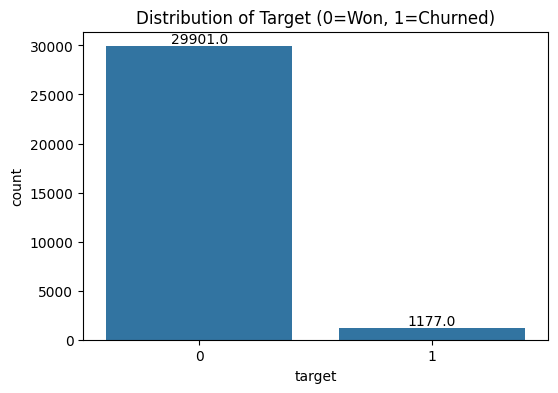

In [10]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='target', data=df_calls)

for p in ax.patches:
    ax.annotate(f'{p.get_height()}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom')

plt.title("Distribution of Target (0=Won, 1=Churned)")
plt.show()

### Class Imbalance Check

In [11]:
counts = df_calls['target'].value_counts()
majority = counts.max()
minority = counts.min()
ratio = majority / minority

print(f"Imbalance Ratio: {ratio:.2f}:1")

if ratio > 3:
    print("\u26a0\ufe0f Highly imbalanced dataset")
elif ratio > 1.5:
    print("\u26a0\ufe0f Moderately imbalanced")
else:
    print("\u2705 Balanced dataset")

Imbalance Ratio: 25.40:1
⚠️ Highly imbalanced dataset


### Missing Values in Target

In [12]:
print("Missing in target:", df_calls['target'].isnull().sum())
print("Missing %:", df_calls['target'].isnull().mean() * 100)

df_calls = df_calls.dropna(subset=['target'])
print("Remaining rows:", len(df_calls))

Missing in target: 0
Missing %: 0.0
Remaining rows: 31078


---
## 3. Univariate Analysis — Numerical

In [13]:
numerical_cols = df_calls.select_dtypes(include=['int64', 'float64']).columns.tolist()
numerical_cols = [col for col in numerical_cols if col != 'target']

print(f"Numerical columns ({len(numerical_cols)}):")
print(numerical_cols)

Numerical columns (3):
['Contact_ID', 'Analysed_Call', 'Call_Year']


In [14]:
summary = df_calls[numerical_cols].describe().T
summary['skew_flag'] = summary['mean'] - summary['50%']
summary

,count,mean,std,min,25%,50%,75%,max,skew_flag
Contact_ID,31078.0,6.416785e+11,4.885094e+10,1.936150e+11,5.949900e+11,6.512520e+11,6.856320e+11,6.918350e+11,-9.573492e+09
Analysed_Call,31078.0,1.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00
Call_Year,31078.0,2.024849e+03,4.120973e-01,2.024000e+03,2.025000e+03,2.025000e+03,2.025000e+03,2.026000e+03,-1.509750e-01


### Distribution Analysis
| Skew Value | Meaning |
|---|---|
| -0.5 to 0.5 | Normal ✅ |
| 0.5 to 1 | Moderate skew ⚠️ |
| > 1 | Highly skewed 🔥 |

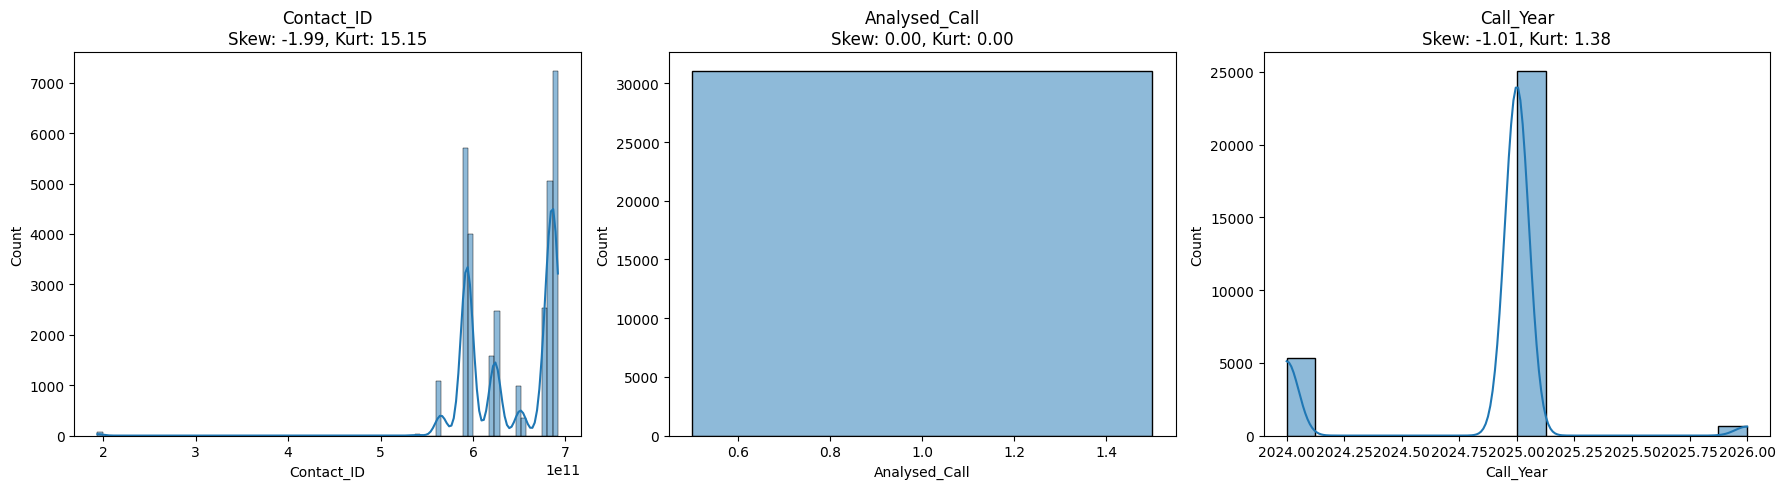

In [15]:
cols = numerical_cols
n_cols = 3
n_rows = math.ceil(len(cols) / n_cols)

plt.figure(figsize=(18, 5 * n_rows))

for i, col in enumerate(cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.histplot(df_calls[col], kde=True)
    skew = df_calls[col].skew()
    kurt = df_calls[col].kurtosis()
    plt.title(f"{col}\nSkew: {skew:.2f}, Kurt: {kurt:.2f}")

plt.tight_layout()
plt.show()

In [16]:
dist_summary = []

for col in numerical_cols:
    skew = df_calls[col].skew()
    kurt = df_calls[col].kurtosis()

    if abs(skew) < 0.5:
        skew_type = 'normal'
    elif abs(skew) < 1:
        skew_type = 'moderate'
    else:
        skew_type = 'high'

    dist_summary.append({
        'column': col,
        'skewness': round(skew, 2),
        'kurtosis': round(kurt, 2),
        'skew_type': skew_type
    })

dist_summary = pd.DataFrame(dist_summary)
dist_summary

,column,skewness,kurtosis,skew_type
0,Contact_ID,-1.99,15.15,high
1,Analysed_Call,0.00,0.00,normal
2,Call_Year,-1.01,1.38,high


### Outlier Detection

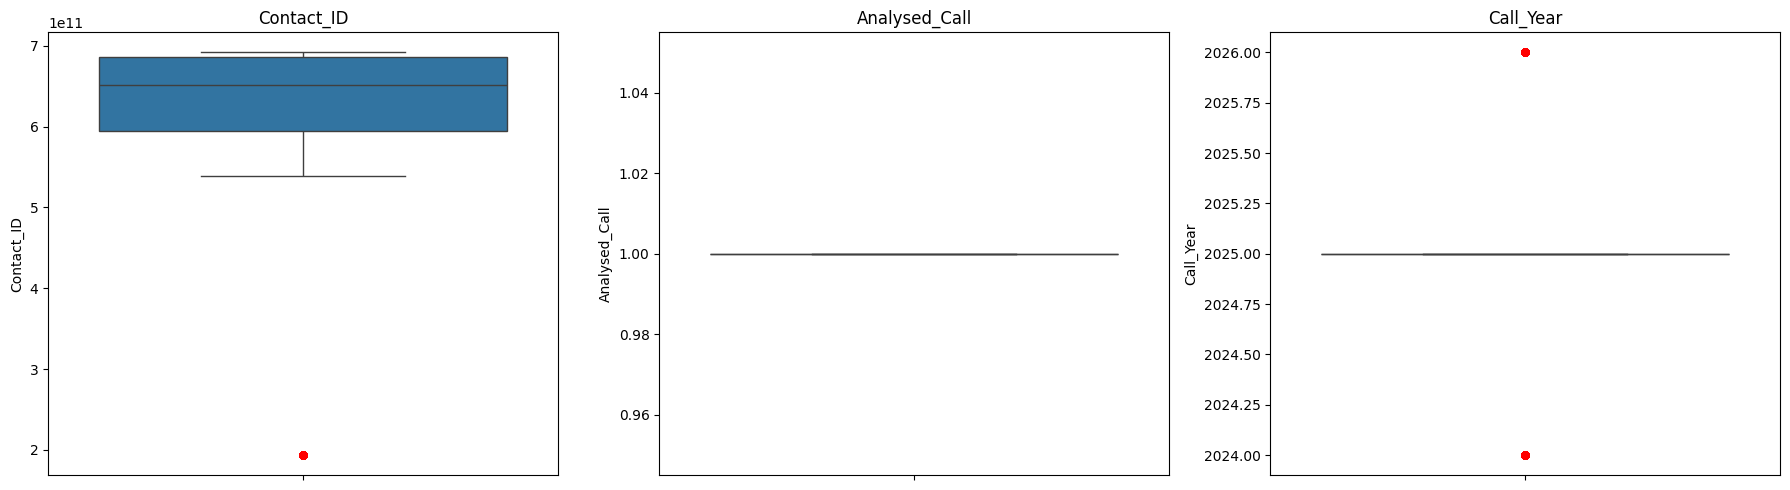

In [17]:
plt.figure(figsize=(18, 5 * n_rows))

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(
        y=df_calls[col],
        flierprops=dict(
            marker='o',
            markerfacecolor='red',
            markeredgecolor='red',
            markersize=5
        )
    )
    plt.title(col)

plt.tight_layout()
plt.show()

In [18]:
outlier_summary = []

for col in numerical_cols:
    Q1 = df_calls[col].quantile(0.25)
    Q3 = df_calls[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df_calls[(df_calls[col] < lower) | (df_calls[col] > upper)]

    outlier_summary.append({
        'column': col,
        'outlier_count': len(outliers),
        'outlier_%': round(len(outliers) / len(df_calls) * 100, 2)
    })

outlier_summary = pd.DataFrame(outlier_summary)
outlier_summary.sort_values(by='outlier_%', ascending=False)

,column,outlier_count,outlier_%
2,Call_Year,5986,19.26
0,Contact_ID,76,0.24
1,Analysed_Call,0,0.00


In [19]:
# TAKE DECISION
# For columns with high outlier % (>5%), decide:
#   - Cap at 99th percentile (clip)
#   - Log transform if skew > 1
#   - Leave as is if outliers are legitimate business values

# Uncomment and adjust as needed:
# for col in numerical_cols:
#     upper = df_calls[col].quantile(0.99)
#     df_calls[col] = df_calls[col].clip(upper=upper)
#     if df_calls[col].skew() > 1:
#         df_calls[col] = np.log1p(df_calls[col])

In [20]:
# Zero, constant, and negative value checks
eda_summary = []

for col in numerical_cols:
    eda_summary.append({
        'column': col,
        'zero_%': round((df_calls[col] == 0).mean() * 100, 2),
        'unique_values': df_calls[col].nunique(),
        'negative_count': (df_calls[col] < 0).sum()
    })

eda_summary = pd.DataFrame(eda_summary)
eda_summary

,column,zero_%,unique_values,negative_count
0,Contact_ID,0.0,494,0
1,Analysed_Call,0.0,1,0
2,Call_Year,0.0,3,0


In [21]:
# TAKE DECISION
# Review zero_% — high zeros may need a binary flag feature (e.g., 'has_calls_flag')
# Review unique_values — columns with 1 unique value are constants → DROP
# Review negative_count — negatives may indicate errors or credit/reversal calls

---
## 4. Univariate Analysis — Categorical

In [22]:
cat_cols = df_calls.select_dtypes(include=['object', 'category']).columns.tolist()
print("Categorical columns:", cat_cols)

Categorical columns: ['Call_Date', 'Direction', 'cc_care_package', 'cc_care_package_discussed', 'cc_urgency_getting_on_site', 'cc_external_consultant', 'cc_agent_cross_sell_attempt', 'cc_customer_issues_concerns', 'cc_business_struggles_financial_hardship', 'cc_call_initiated_by', 'cc_questionnaire_completion', 'cc_chasing_response', 'cc_issues_within_questionnaire', 'cc_login_issues', 'cc_platform_issues', 'cc_dissatisfaction_time_to_complete', 'cc_process_complexity_concerns', 'cc_questions_harder_than_expected', 'cc_dissatisfaction_support', 'cc_contractor_sentiment', 'cc_contractor_sentiment_start_score', 'cc_contractor_sentiment_end_score', 'cc_contractor_sentiment_overall_score', 'cc_contractor_sentiment_issues_score', 'cc_pricing_mentioned', 'cc_pricing_sentiment_impact', 'cc_refund_discussed', 'cc_contractor_suggest_leave', 'cc_contractor_complained', 'Co_Ref']


In [23]:
# Check numerical columns that are actually categorical (low cardinality)
for col in df_calls.select_dtypes(include=['int64', 'float64']).columns:
    if df_calls[col].nunique() < 15 and col != 'target':
        print(f"{col} → {df_calls[col].nunique()} unique values")

Analysed_Call → 1 unique values
Call_Year → 3 unique values


In [24]:
# TAKE DECISION
# Add any low-cardinality numerical columns that should be treated as categorical
# Example: cat_cols += ['Some_Flag_Column']

cat_cols = list(set(cat_cols))  # remove duplicates
print("Final categorical columns:", cat_cols)

Final categorical columns: ['cc_external_consultant', 'cc_login_issues', 'cc_pricing_mentioned', 'cc_questionnaire_completion', 'cc_questions_harder_than_expected', 'Call_Date', 'cc_care_package_discussed', 'Direction', 'cc_business_struggles_financial_hardship', 'cc_issues_within_questionnaire', 'cc_dissatisfaction_support', 'cc_contractor_sentiment_issues_score', 'cc_platform_issues', 'cc_contractor_sentiment_end_score', 'cc_refund_discussed', 'cc_agent_cross_sell_attempt', 'cc_urgency_getting_on_site', 'cc_care_package', 'cc_dissatisfaction_time_to_complete', 'cc_contractor_complained', 'cc_process_complexity_concerns', 'cc_contractor_sentiment', 'cc_customer_issues_concerns', 'cc_contractor_suggest_leave', 'cc_contractor_sentiment_overall_score', 'cc_chasing_response', 'cc_call_initiated_by', 'cc_pricing_sentiment_impact', 'Co_Ref', 'cc_contractor_sentiment_start_score']


### Value Counts & Distribution

In [25]:
summary = []

for col in cat_cols:
    vc = df_calls[col].value_counts(normalize=True, dropna=False)
    summary.append({
        'column': col,
        'unique_values': df_calls[col].nunique(),
        'top_category': vc.index[0],
        'top_%': round(vc.iloc[0] * 100, 2),
        'missing_%': round(df_calls[col].isna().mean() * 100, 2)
    })

summary_df = pd.DataFrame(summary).sort_values(by='top_%', ascending=False)
summary_df

,column,unique_values,top_category,top_%,missing_%
4,cc_questions_harder_than_expected,7,No,99.49,0.10
14,cc_refund_discussed,3,no,99.11,0.00
10,cc_dissatisfaction_support,4,No,97.75,0.10
23,cc_contractor_suggest_leave,63,No,97.05,0.31
8,cc_business_struggles_financial_hardship,6,No,96.52,0.42
27,cc_pricing_sentiment_impact,3,no,96.46,0.00
15,cc_agent_cross_sell_attempt,23,No,95.80,0.42
18,cc_dissatisfaction_time_to_complete,3,No,95.55,0.09
1,cc_login_issues,12,No,94.91,0.09
12,cc_platform_issues,4,No,93.09,0.09


### Identify Problem Columns

In [26]:
# Low variance (>95% dominated by one category)
low_var_cols = []

for col in cat_cols:
    top_pct = df_calls[col].value_counts(normalize=True, dropna=False).iloc[0]
    if top_pct > 0.95:
        low_var_cols.append(col)

print("Low variance columns:", low_var_cols)

# High cardinality
high_card_cols = [col for col in cat_cols if df_calls[col].nunique() > 50]
print("High cardinality columns:", high_card_cols)

Low variance columns: ['cc_questions_harder_than_expected', 'cc_business_struggles_financial_hardship', 'cc_dissatisfaction_support', 'cc_refund_discussed', 'cc_agent_cross_sell_attempt', 'cc_dissatisfaction_time_to_complete', 'cc_contractor_suggest_leave', 'cc_pricing_sentiment_impact']
High cardinality columns: ['Call_Date', 'cc_issues_within_questionnaire', 'cc_care_package', 'cc_contractor_sentiment', 'cc_contractor_suggest_leave', 'cc_chasing_response', 'Co_Ref']


In [27]:
# TAKE DECISION
# Low variance columns → likely DROP (they carry almost no signal)
# High cardinality columns → consider target encoding, grouping, or DROP

# cols_to_drop = low_var_cols + []
# df_calls.drop(columns=cols_to_drop, inplace=True)

### Bar Chart Visualization

C:\Users\Asus\AppData\Local\Temp\ipykernel_40444\3917313514.py:14: UserWarning: Tight layout not applied. tight_layout cannot make axes width small enough to accommodate all axes decorations
  plt.tight_layout()


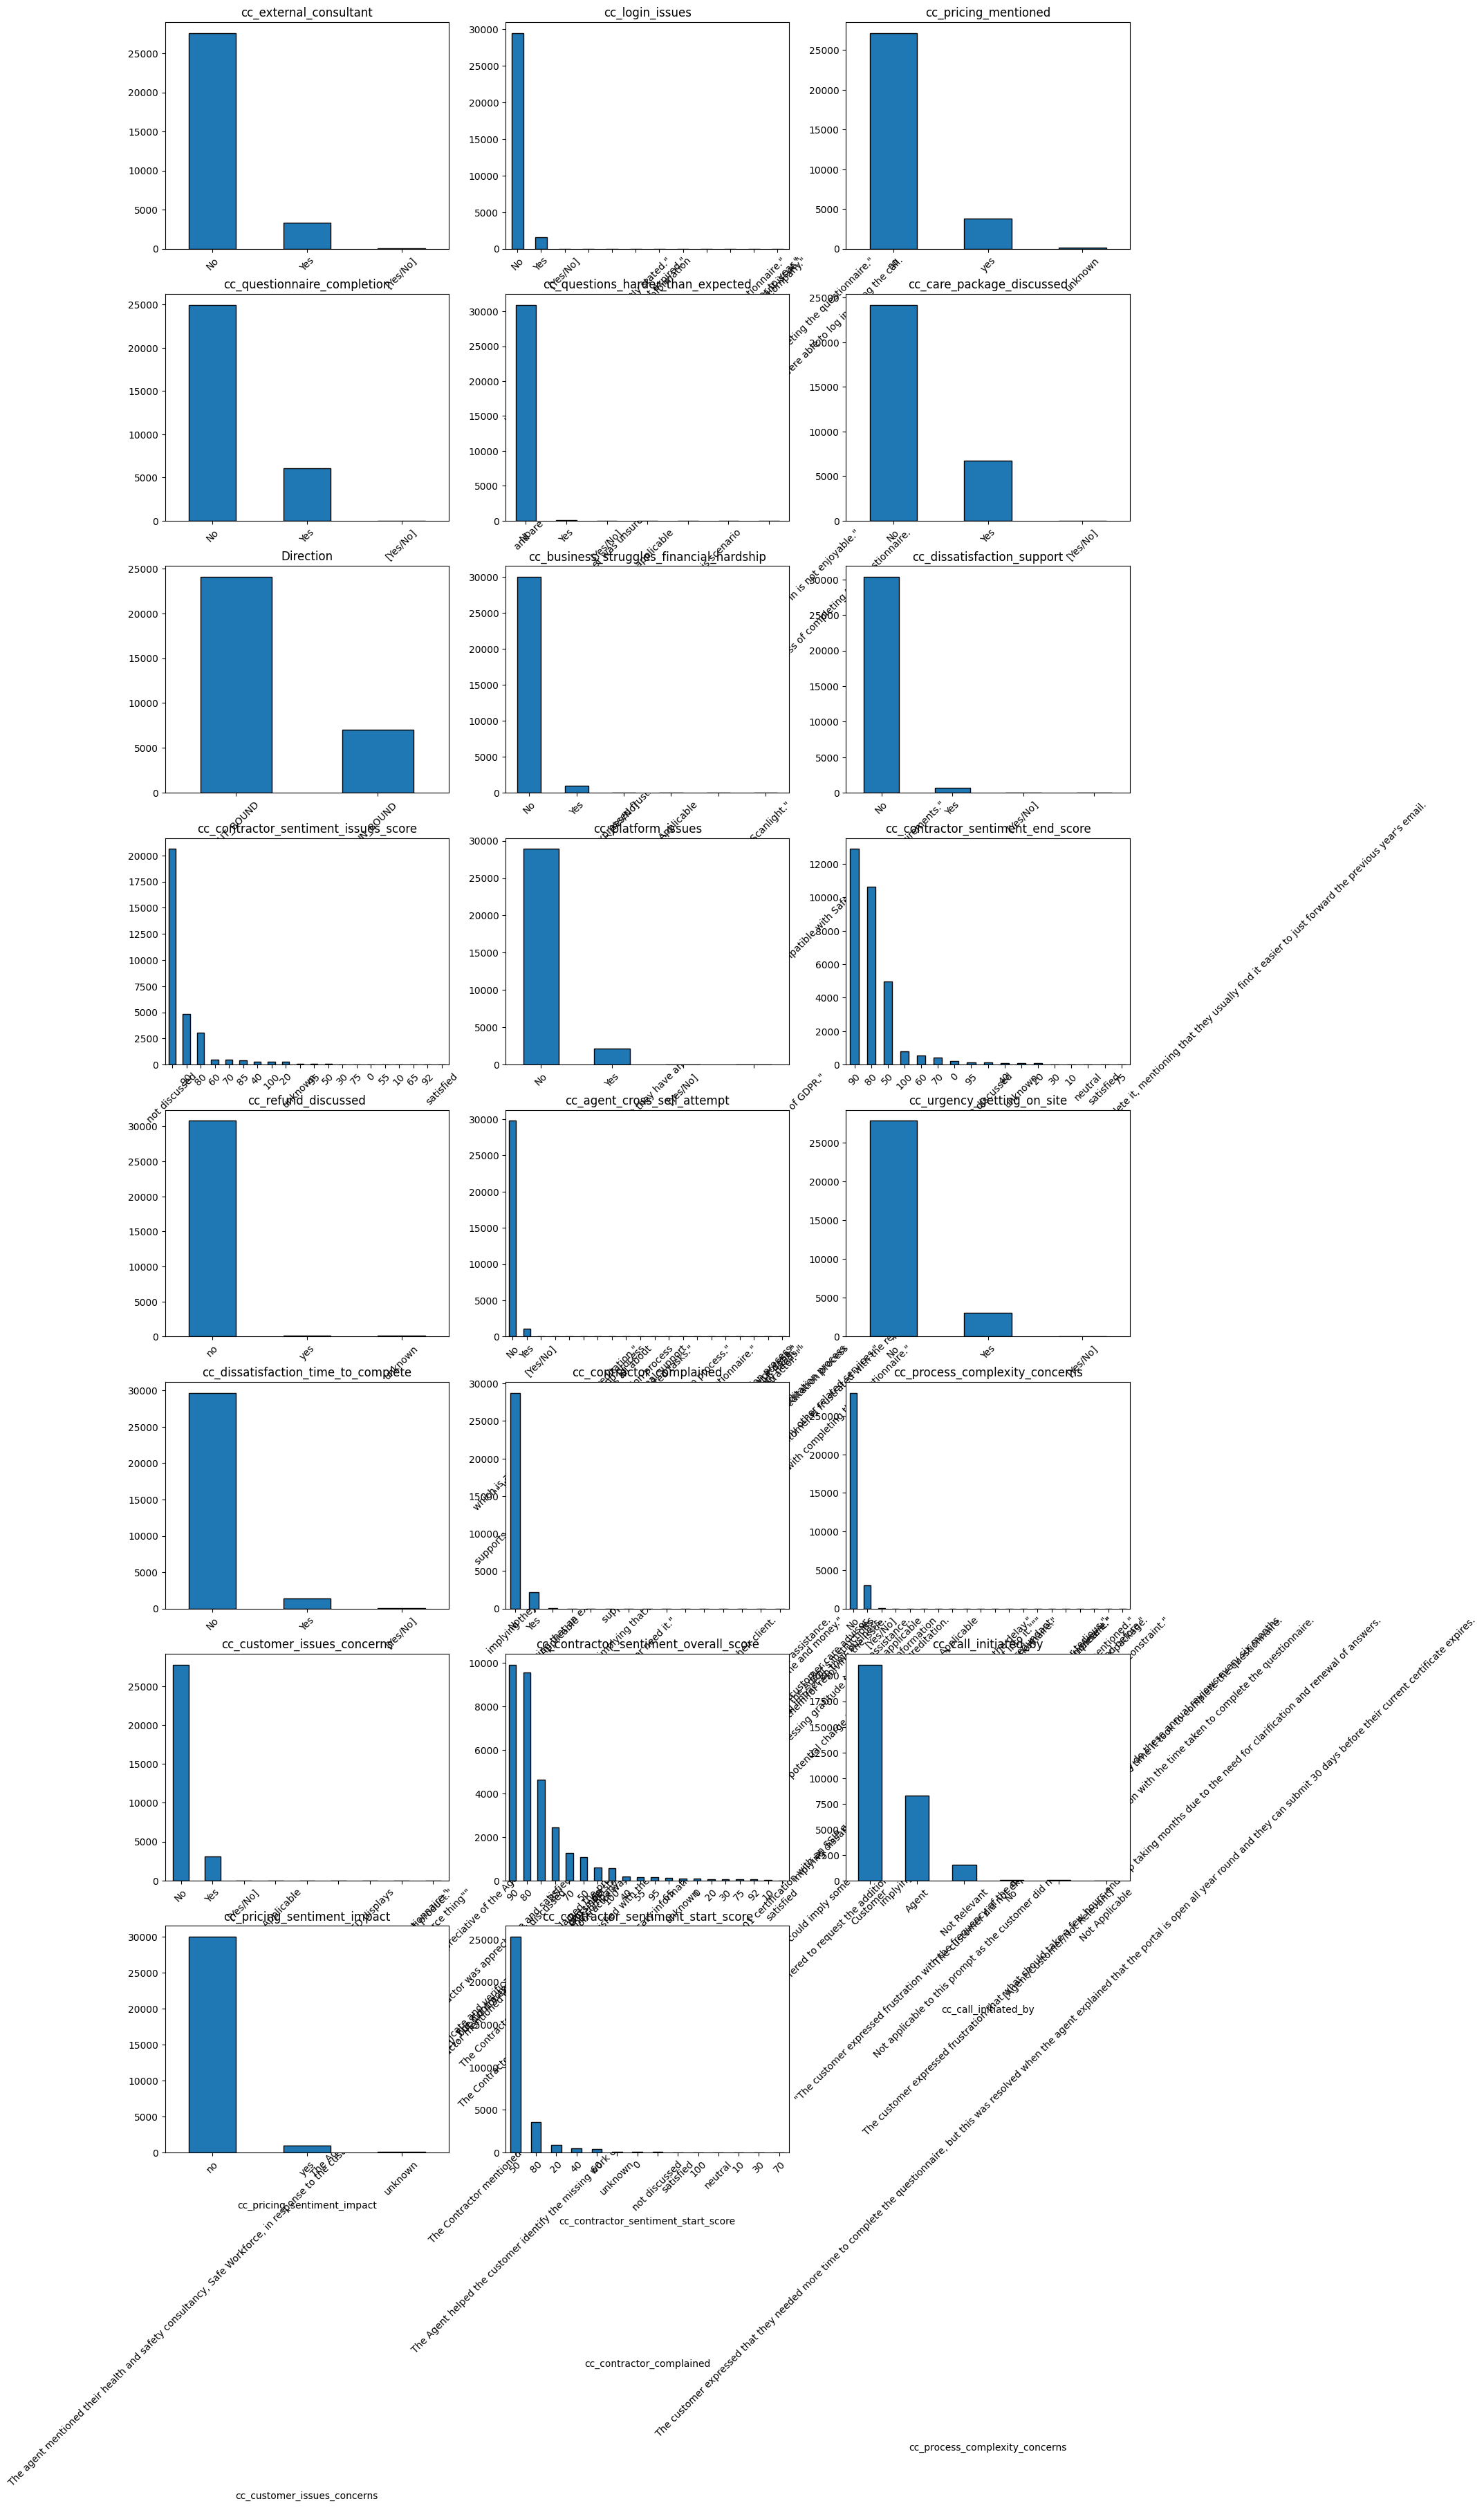

In [28]:
cols_to_plot = [col for col in cat_cols if df_calls[col].nunique() <= 50]
n_cols = 3
n_rows = math.ceil(len(cols_to_plot) / n_cols)

plt.figure(figsize=(18, 5 * n_rows))

for i, col in enumerate(cols_to_plot, 1):
    plt.subplot(n_rows, n_cols, i)
    vc = df_calls[col].value_counts().head(20)
    vc.plot(kind='bar', edgecolor='black')
    plt.title(col)
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

---
## 5. Bivariate Analysis

### Numerical Features vs Churn

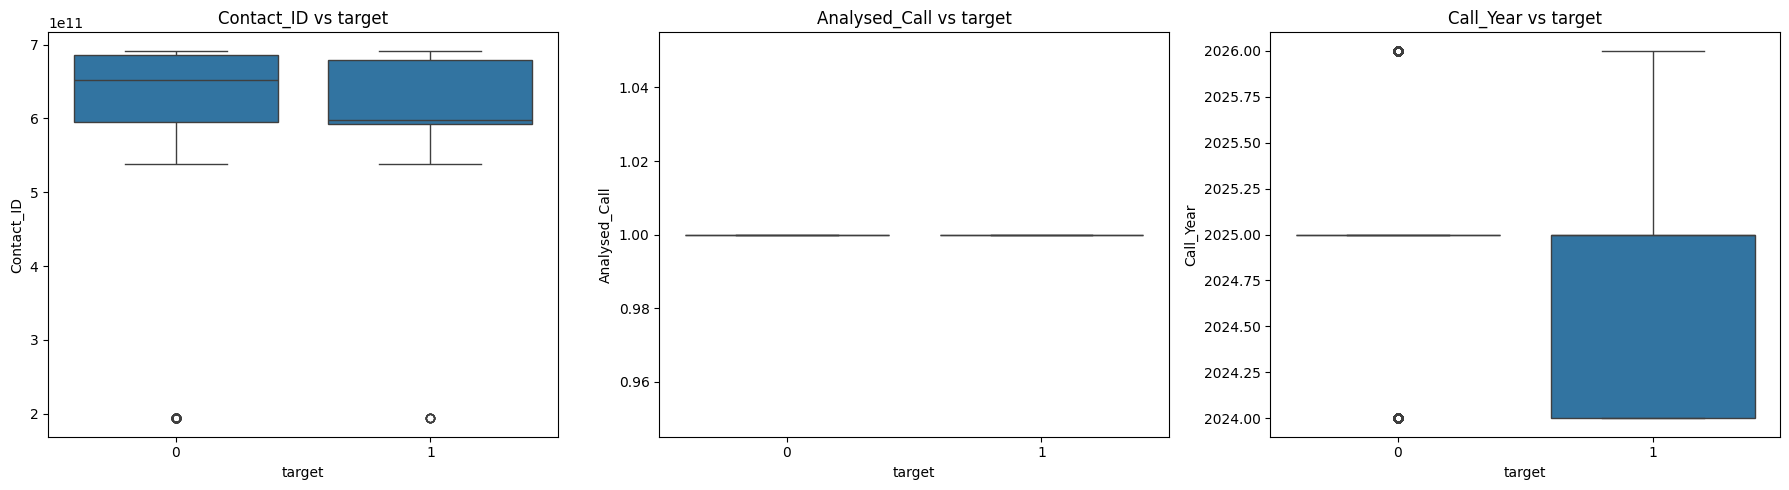

In [29]:
num_cols = [col for col in numerical_cols if col != 'target']

n_cols = 3
n_rows = math.ceil(len(num_cols) / n_cols)

plt.figure(figsize=(18, 5 * n_rows))

for i, col in enumerate(num_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(x='target', y=col, data=df_calls)
    plt.title(f"{col} vs target")

plt.tight_layout()
plt.show()

In [30]:
df_calls.groupby('target')[num_cols].mean().T.round(2)

target,0,1
Contact_ID,6.423341e+11,6.250233e+11
Analysed_Call,1.000000e+00,1.000000e+00
Call_Year,2.024850e+03,2.024760e+03


In [31]:
# TAKE DECISION
# Highlight features where the mean differs significantly between target=0 and target=1
# These are likely strong predictors → mark them ⭐

### Categorical Features vs Churn

C:\Users\Asus\AppData\Local\Temp\ipykernel_40444\2797773040.py:20: UserWarning: Tight layout not applied. tight_layout cannot make axes height small enough to accommodate all axes decorations.
  plt.tight_layout()


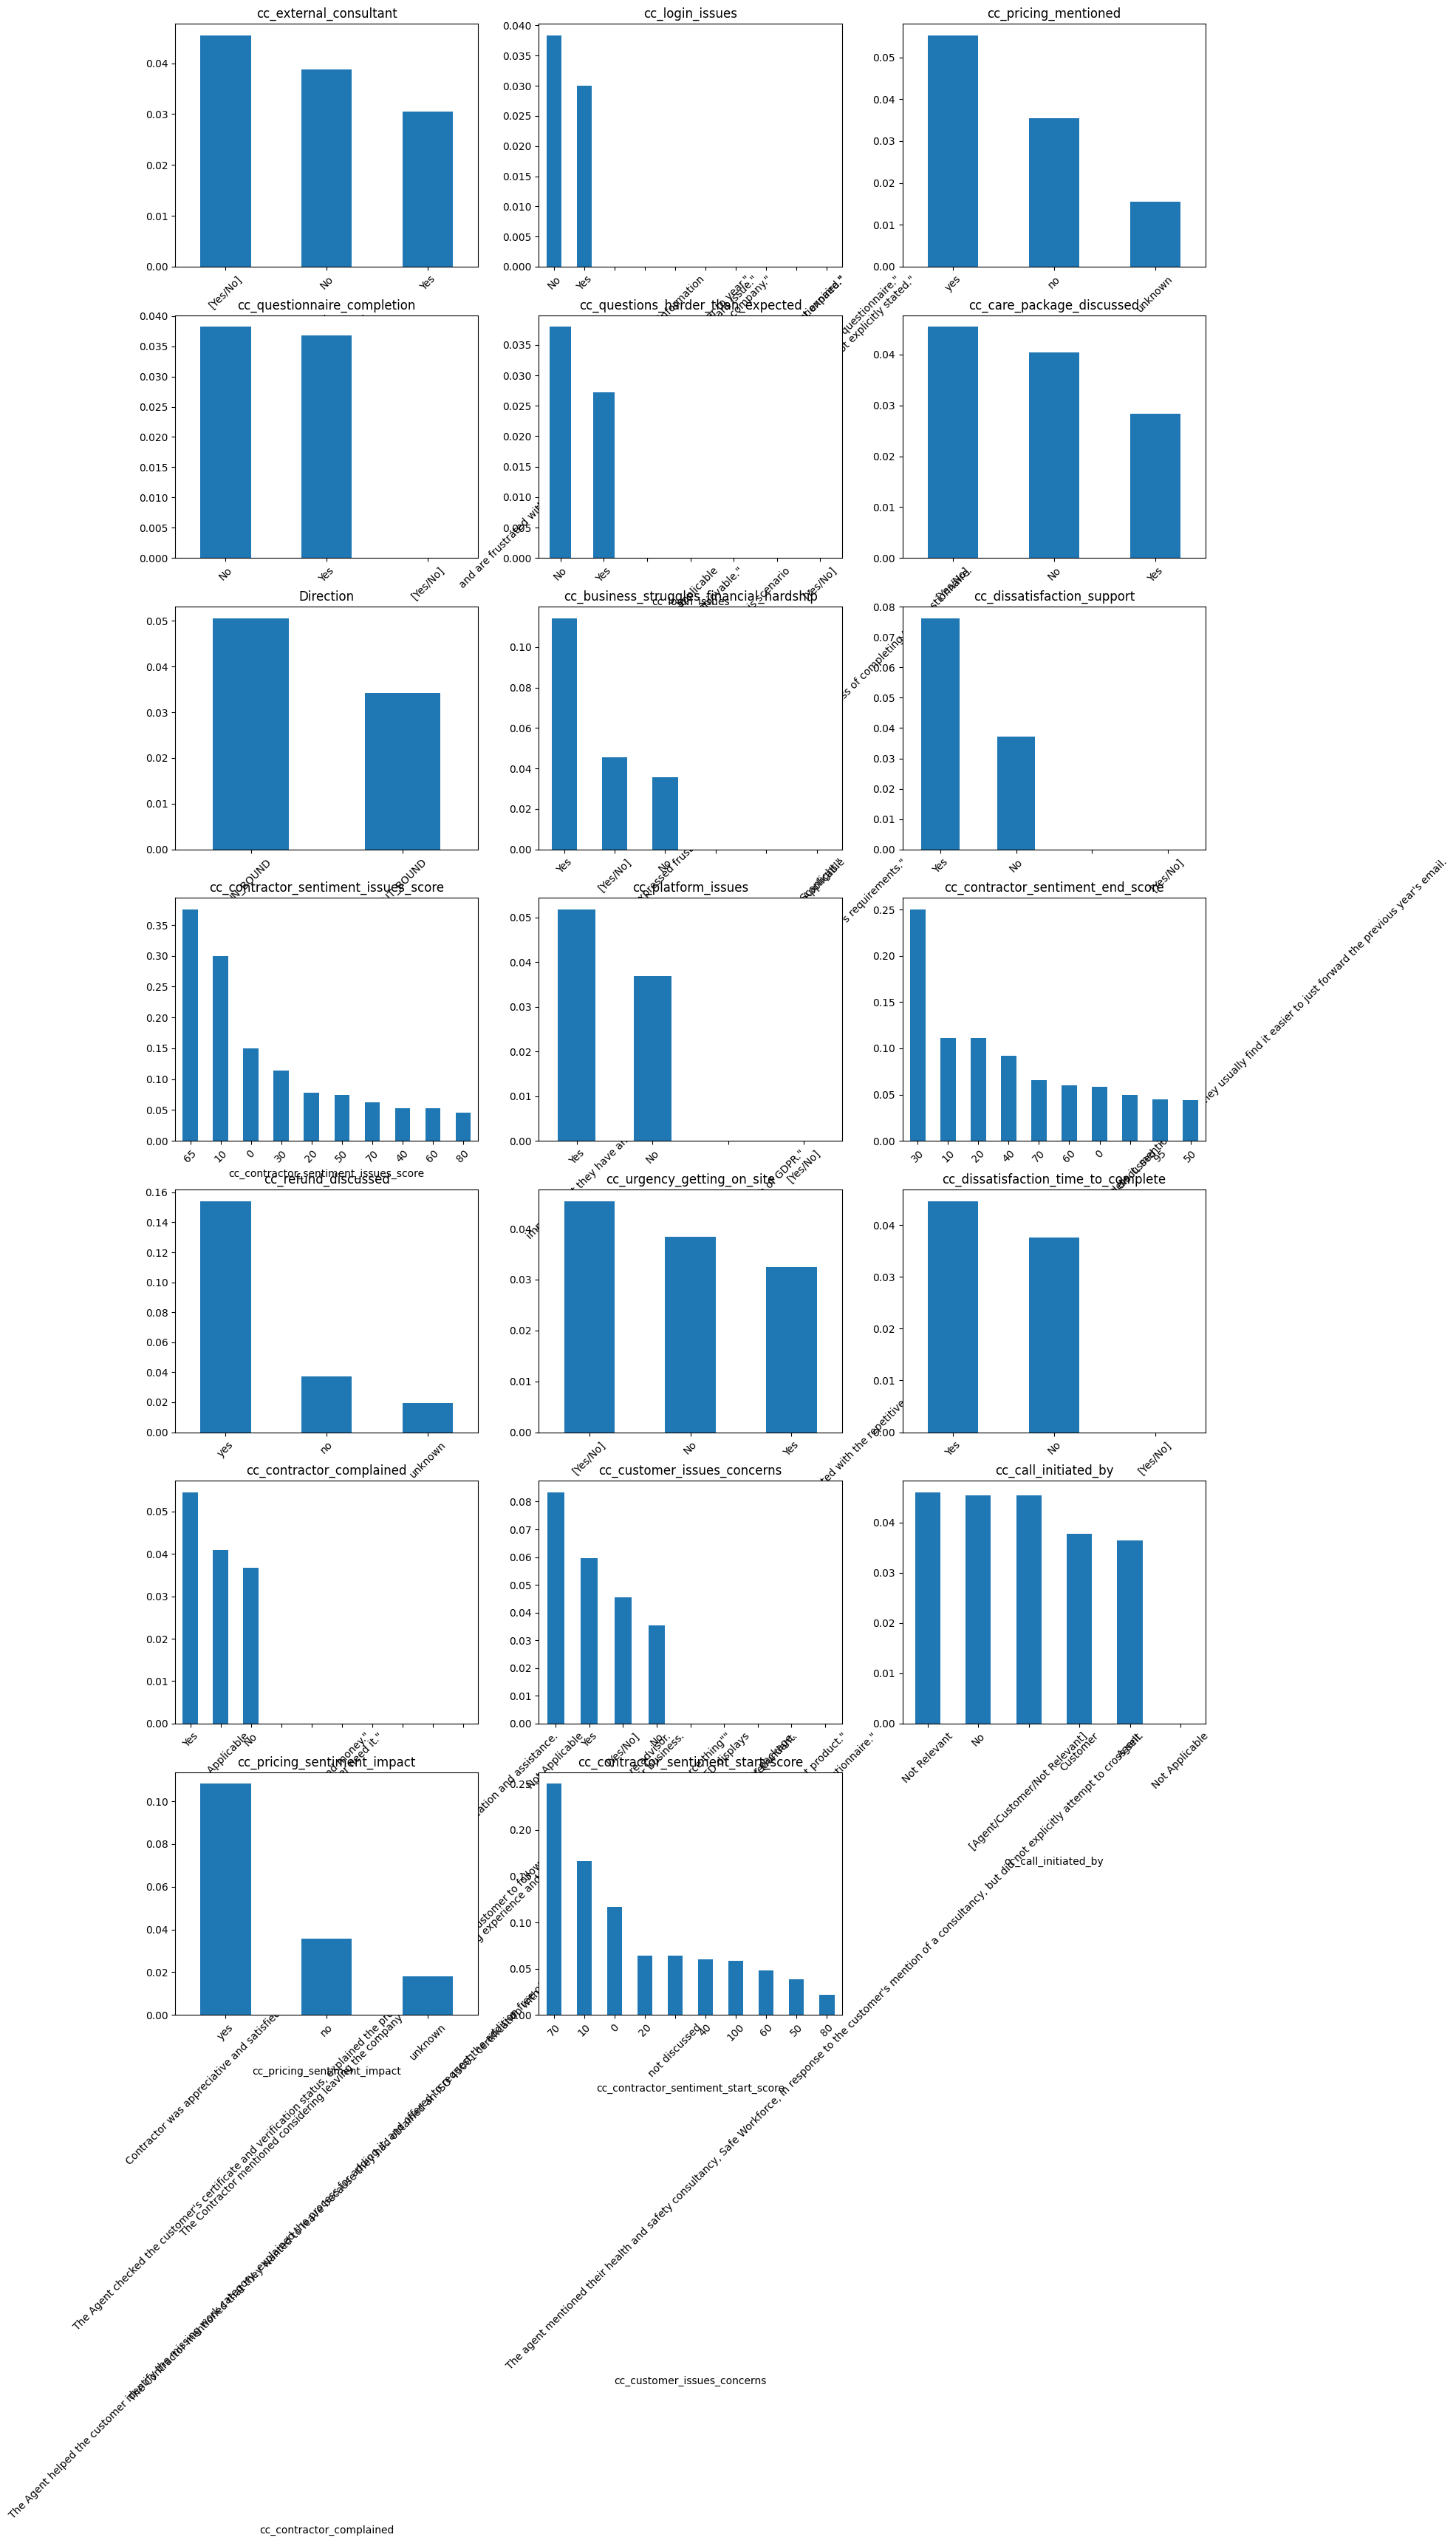

In [32]:
cols = [c for c in cat_cols if df_calls[c].nunique() <= 20]

n_cols = 3
n_rows = math.ceil(len(cols) / n_cols)

plt.figure(figsize=(18, 5 * n_rows))

for i, col in enumerate(cols, 1):
    plt.subplot(n_rows, n_cols, i)
    churn_rate = (
        df_calls.groupby(col, observed=True)['target']
        .mean()
        .sort_values(ascending=False)
        .head(10)
    )
    churn_rate.plot(kind='bar')
    plt.title(col)
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

---
## 6. Business Feature Engineering

In [33]:
# TAKE DECISION
# Based on available cc_calls columns, engineer domain-relevant features.
# Common ideas for call centre data:
#
#   df_calls['calls_per_month'] = df_calls['Total_Calls'] / df_calls['Tenure_Months']
#   df_calls['avg_call_duration'] = df_calls['Total_Duration'] / df_calls['Total_Calls']
#   df_calls['complaint_rate'] = df_calls['Complaint_Calls'] / df_calls['Total_Calls']
#   df_calls['resolved_rate'] = df_calls['Resolved_Calls'] / df_calls['Total_Calls']
#
# Review your columns above and add relevant features below:

# Example (update to match your actual column names):
# df_calls['example_feature'] = df_calls['col_a'] / (df_calls['col_b'] + 1)

In [34]:
# Check what was added vs original
added = df_calls.columns.difference(db_calls_temp.columns)
removed = db_calls_temp.columns.difference(df_calls.columns)

print("Added columns:", list(added))
print("Removed columns:", list(removed))

Added columns: []
Removed columns: []


---
## 7. Correlation Analysis

### Feature vs Feature Correlation

In [35]:
num_cols_corr = df_calls.select_dtypes(include=['int64', 'float64']).columns.tolist()

# TAKE DECISION — exclude non-meaningful ID-like columns below
cols_to_exclude = [JOIN_KEY]  # Add more if needed, e.g. ['Co_Ref', 'Call_ID']
num_cols_corr = [col for col in num_cols_corr if col not in cols_to_exclude]

print(f"Number of numerical columns for correlation: {len(num_cols_corr)}")

Number of numerical columns for correlation: 4


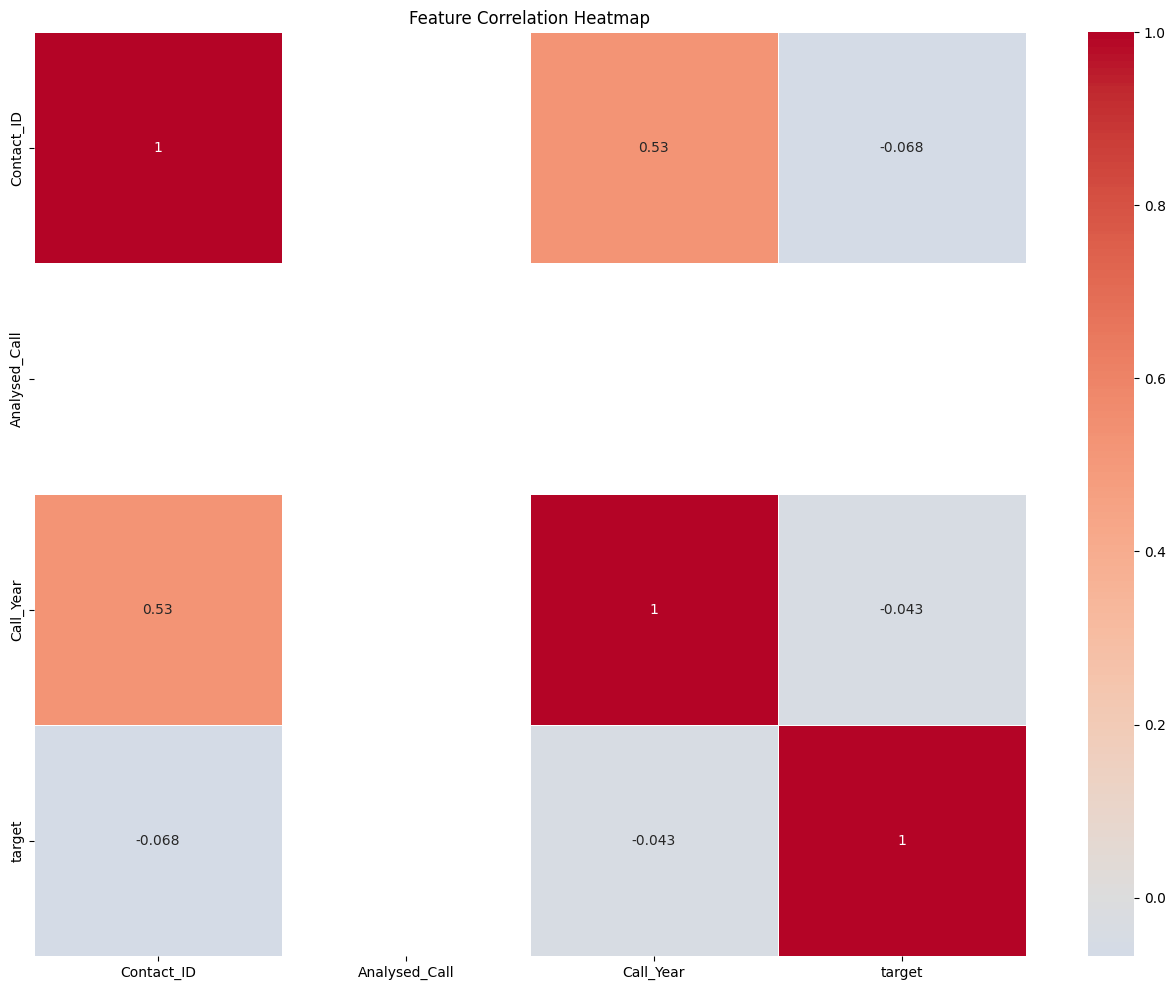

In [36]:
corr_matrix = df_calls[num_cols_corr].corr()

plt.figure(figsize=(16, 12))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    center=0,
    linewidths=0.5
)
plt.title("Feature Correlation Heatmap")
plt.show()

In [37]:
# Identify high-correlation pairs
threshold = 0.8
high_corr_pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        val = corr_matrix.iloc[i, j]
        if abs(val) > threshold:
            col1 = corr_matrix.columns[i]
            col2 = corr_matrix.columns[j]
            high_corr_pairs.append((col1, col2, round(val, 3)))

high_corr_pairs = sorted(high_corr_pairs, key=lambda x: abs(x[2]), reverse=True)

for pair in high_corr_pairs:
    print(f"{pair[0]} ↔ {pair[1]} : {pair[2]}")

In [38]:
# TAKE DECISION
# For each highly-correlated pair (>0.8), decide which to keep:
#   ✔ Keep the one with stronger correlation to target
#   ✔ Keep the one with clearer business meaning
#
# Interpretation guide:
#   > 0.9  → Almost identical → drop one
#   0.8-0.9 → Related → check vs target, keep best
#   < 0.8  → Keep both

# features_to_drop = []
# df_calls.drop(columns=features_to_drop, inplace=True)

### Feature vs Churn Correlation

target           1.000000
Call_Year       -0.043483
Contact_ID      -0.067644
Analysed_Call         NaN
Name: target, dtype: float64


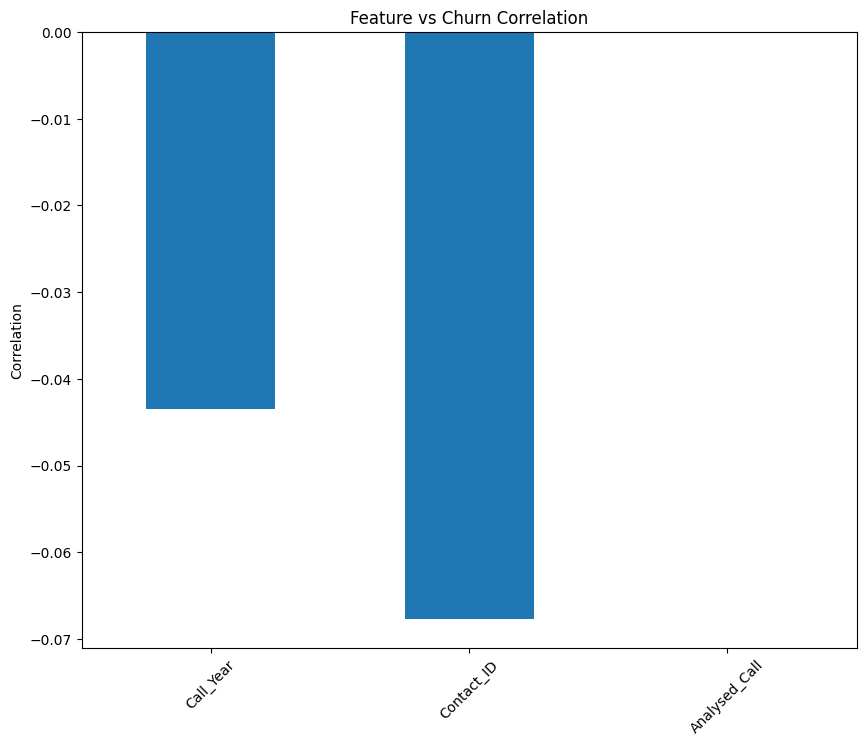

In [39]:
churn_corr = df_calls[num_cols_corr].corr()['target'].sort_values(ascending=False)
print(churn_corr)

plt.figure(figsize=(10, 8))
churn_corr.drop('target').plot(kind='bar')
plt.title("Feature vs Churn Correlation")
plt.ylabel("Correlation")
plt.xticks(rotation=45)
plt.show()

In [40]:
print("\U0001f534 Top features increasing churn:")
print(churn_corr.head(10))

print("\n\U0001f7e2 Top features reducing churn:")
print(churn_corr.tail(10))

🔴 Top features increasing churn:
target           1.000000
Call_Year       -0.043483
Contact_ID      -0.067644
Analysed_Call         NaN
Name: target, dtype: float64

🟢 Top features reducing churn:
target           1.000000
Call_Year       -0.043483
Contact_ID      -0.067644
Analysed_Call         NaN
Name: target, dtype: float64


### Point-Biserial Correlation

In [41]:
from scipy.stats import pointbiserialr

df_corr = df_calls.copy()

num_cols_pb = [col for col in num_cols_corr if col != 'target']
df_corr[num_cols_pb] = df_corr[num_cols_pb].replace([np.inf, -np.inf], np.nan)
df_corr = df_corr.dropna(subset=['target'])

results = []

for col in num_cols_pb:
    temp_df = df_corr[[col, 'target']].dropna()
    if len(temp_df) > 0:
        corr, pval = pointbiserialr(temp_df['target'], temp_df[col])
        results.append({
            'feature': col,
            'correlation': round(corr, 3),
            'p_value': round(pval, 4)
        })

pb_df = pd.DataFrame(results).sort_values(by='correlation', ascending=False)
print("\n\U0001f539 Point-Biserial Results:")
print(pb_df)


🔹 Point-Biserial Results:
         feature  correlation  p_value
2      Call_Year       -0.043      0.0
0     Contact_ID       -0.068      0.0
1  Analysed_Call          NaN      NaN


C:\Users\Asus\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:5546: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rpb, prob = pearsonr(x, y)


In [42]:
important_features = pb_df[
    (pb_df['p_value'] < 0.05) & (abs(pb_df['correlation']) > 0.05)
]

print("\U0001f525 Statistically Important Features (p<0.05, |corr|>0.05):")
print(important_features)

🔥 Statistically Important Features (p<0.05, |corr|>0.05):
      feature  correlation  p_value
0  Contact_ID       -0.068      0.0


---
## 8. Categorical vs Target (Churn Rate by Category)

In [43]:
cat_corr = []

for col in cat_cols:
    churn_rate = df_calls.groupby(col)['target'].mean()
    for category, rate in churn_rate.items():
        cat_corr.append({
            'feature': col,
            'category': category,
            'churn_rate': round(rate, 3)
        })

cat_corr_df = pd.DataFrame(cat_corr)
cat_corr_df.sort_values(by='churn_rate', ascending=False).head(20)

,feature,category,churn_rate
11076,Co_Ref,QV9483,1.0
7853,Co_Ref,LT6551,1.0
8120,Co_Ref,ME3334,1.0
8114,Co_Ref,ME2054,1.0
8091,Co_Ref,MD2038,1.0
8085,Co_Ref,MD0422,1.0
8066,Co_Ref,MC2363,1.0
8064,Co_Ref,MC1522,1.0
8040,Co_Ref,MB0620,1.0
8019,Co_Ref,MA3482,1.0


In [44]:
# TAKE DECISION
# Review high-churn categories.
# Some categories with very high/low churn rates may need to be grouped or encoded carefully.

---
## 9. Final Summary & Column Tracking

In [45]:
added = df_calls.columns.difference(db_calls_temp.columns)
removed = db_calls_temp.columns.difference(df_calls.columns)

print(f"Total columns now: {len(df_calls.columns)}")
print(f"Added columns: {list(added)}")
print(f"Removed columns: {list(removed)}")

Total columns now: 34
Added columns: []
Removed columns: []


In [46]:
# TAKE DECISION
# Final review before saving:
#   1. Drop any remaining low-signal or redundant columns
#   2. Confirm all engineered features look correct
#   3. Confirm target distribution is what you expect

print("Final target distribution:")
print(df_calls['target'].value_counts())
print("\nFinal shape:", df_calls.shape)

Final target distribution:
target
0    29901
1     1177
Name: count, dtype: int64

Final shape: (31078, 34)


In [47]:
# Save EDA output
import os
os.makedirs('../../dataset/03_EDA/cc_calls', exist_ok=True)
df_calls.to_csv('../../dataset/03_EDA/cc_calls/cc_calls_eda.csv', index=False)
print("Saved to dataset/03_EDA/cc_calls/cc_calls_eda.csv")

Saved to dataset/03_EDA/cc_calls/cc_calls_eda.csv
